<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.


Importamos las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

print("TensorFlow:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Descargamos el dataset de traducción de Español-Inglés

In [2]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de líneas disponibles en el dataset: {len(lines)}")

Total de líneas disponibles en el dataset: 118964


Definimos el número máximo de oraciones y la semilla.

**Extensión respecto de la clase:** en el notebook de referencia se usaban `MAX_NUM_SENTENCES = 10000`. Acá lo llevamos a **110.000** oraciones para darle más datos al modelo y así poder aprovechar mejor las capas LSTM más grandes que vamos a probar.

In [3]:
MAX_NUM_SENTENCES = 110000  # Antes: 10000. Ahora el dataset es más amplio

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 110000


In [5]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Analizamos brevemente la longitud de las oraciones

Longitud promedio (EN): 6.31 | percentil 95: 11.0 | máximo: 47
Longitud promedio (ES): 7.09 | percentil 95: 12.0 | máximo: 50


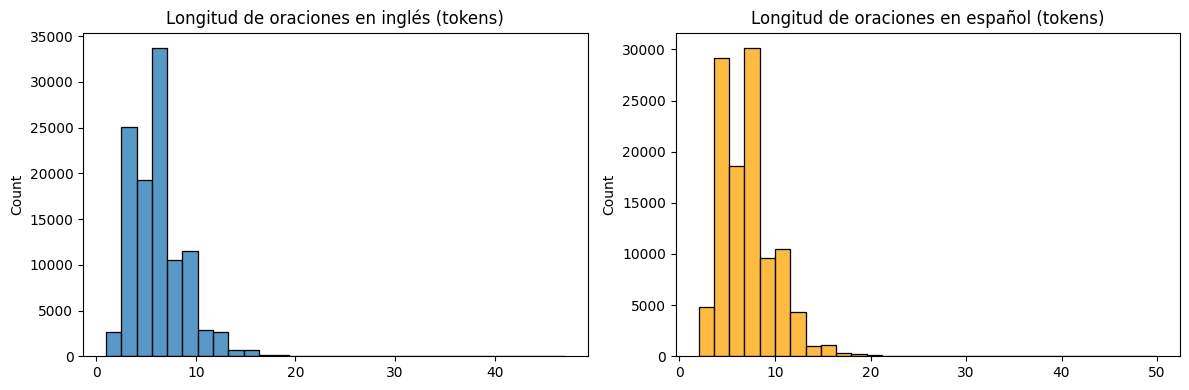

In [6]:
input_lengths = [len(s.split()) for s in input_sentences]
output_lengths = [len(s.split()) for s in output_sentences]

print(f"Longitud promedio (EN): {np.mean(input_lengths):.2f} | percentil 95: {np.percentile(input_lengths, 95):.1f} | máximo: {max(input_lengths)}")
print(f"Longitud promedio (ES): {np.mean(output_lengths):.2f} | percentil 95: {np.percentile(output_lengths, 95):.1f} | máximo: {max(output_lengths)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(input_lengths, bins=30, ax=axes[0])
axes[0].set_title("Longitud de oraciones en inglés (tokens)")
sns.histplot(output_lengths, bins=30, ax=axes[1], color='orange')
axes[1].set_title("Longitud de oraciones en español (tokens)")
plt.tight_layout()
plt.show()

Aplicamos tokenización

In [7]:
MAX_VOCAB_SIZE = 12000  # Antes: 8000. Vocabulario más amplio dado el dataset más grande.

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 12000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

#output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_tokenizer.fit_on_texts(output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
sos_idx = word2idx_outputs['<sos>']
eos_idx = word2idx_outputs['<eos>']
print(f"idx(<sos>) = {sos_idx} | idx(<eos>) = {eos_idx} | num_words_output = {num_words_output}")
assert sos_idx < num_words_output and eos_idx < num_words_output, \
    "<sos>/<eos> quedaron fuera del vocabulario efectivo"

# Secuencias más largas respecto de la notebook de clase: (max_input_len=20, max_out_len=22)
max_input_len = 25
max_out_len   = 27

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

idx(<sos>) = 2 | idx(<eos>) = 1 | num_words_output = 12000
Vocabulario EN: 13170 | ES: 25496
max_input_len=25  max_out_len=27


Aplicamos padding a las secuencias

In [8]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [9]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0  784 1198   18  104]
[   2  155 1404   22  217    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]
[ 155 1404   22  217    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0]


Definimos función para obtener un `tf.data.Dataset`.

Esta función construye un `tf.data.Dataset` que genera batches de `(encoder_in, decoder_in)` a targets enteros (índices de palabra), compatibles con `sparse_categorical_crossentropy`.

In [10]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        (enc_seqs.astype(np.int32), dec_in_seqs.astype(np.int32)),
        dec_out_seqs.astype(np.int32),
    ))
    if shuffle:
        ds = ds.shuffle(len(enc_seqs), reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Aplicamos la función en el dataset para obtener el train y validation set

In [11]:
BATCH_SIZE = 256
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output, shuffle=True
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Oraciones de entrenamiento: {split_idx} | Oraciones de validación: {len(encoder_input_sequences) - split_idx}")

Oraciones de entrenamiento: 93500 | Oraciones de validación: 16500


Definimos función para descargar los embeddings de GloVe

In [12]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=7b3ee6a9-4bd9-4e3a-897e-ef29c0b853f1
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:02<00:00, 258MB/s]

Descarga completada.


Definimos función para cargar los embeddings de GloVe

In [13]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

Definimos función para obtener el embedding por palabra

In [14]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

Definimos función para armar la matriz de embeddings

In [15]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [16]:
EMBED_DIM = 50
#nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)} / {nb_words}")

Embeddings nulos: 673 / 12000


### **Modelo Seq2Seq**

Definimos función para armar el encoder. Esta función devuelve (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer) para poder reusar las capas en el modelo de inferencia.

In [17]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.1, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

Definimos función para armar el decoder. Esta función devuelve (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer)
    para reusar las capas en inferencia.

In [18]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        mask_zero=True,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

Envolvemos la construcción + compilación del modelo completo en una función `build_model(...)`, parametrizada por `n_units`. Esto nos permite entrenar varias configuraciones de forma sistemática para el análisis de hiperparámetros.

In [19]:
def build_model(nb_words, embed_dim, embedding_matrix, max_input_len,
                 num_words_output, max_out_len, n_units, lr=1e-3):

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, embed_dim, embedding_matrix, max_input_len, n_units
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    components = {
        'enc_inputs': enc_inputs, 'enc_emb_layer': enc_emb_layer, 'enc_lstm_layer': enc_lstm_layer,
        'dec_inputs': dec_inputs, 'dec_emb_layer': dec_emb_layer, 'dec_lstm_layer': dec_lstm_layer,
        'dec_dense_layer': dec_dense_layer,
    }
    return model, components



### **Comparación de hiperparámetros: número de unidades LSTM**

En lugar de fijar `n_units = 256`, entrenamos **tres configuraciones** (128, 256 y 512 unidades) sobre el mismo dataset y las mismas secuencias, y comparamos:

* Accuracy y loss de entrenamiento y validación.
* Cantidad de parámetros entrenables de cada modelo.
* Tiempo de entrenamiento por época (proxy del costo computacional).

Cada configuración usa los mismos callbacks (`ReduceLROnPlateau` + `EarlyStopping`) para que la comparación sea justa.

In [20]:
tf.keras.utils.set_random_seed(42)
UNIT_CONFIGS = [128, 256, 512]
EPOCHS_SEARCH = 50

histories = {}
results = {}
trained_models = {}

for n_units in UNIT_CONFIGS:
    print(f"\n{'='*70}\nEntrenando modelo con n_units = {n_units}\n{'='*70}")
    tf.keras.backend.clear_session()

    model, components = build_model(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len,
        num_words_output, max_out_len, n_units
    )

    n_params = model.count_params()
    print(f"Parámetros entrenables: {n_params:,}")

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
    )

    t0 = time.time()
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_SEARCH,
        callbacks=[lr_scheduler, early_stop],
        verbose=2
    )
    elapsed = time.time() - t0
    n_epochs_run = len(hist.history['loss'])

    histories[n_units] = hist.history
    trained_models[n_units] = (model, components)
    results[n_units] = {
        'n_units': n_units,
        'parametros': n_params,
        'epocas_entrenadas': n_epochs_run,
        'seg_por_epoca': elapsed / n_epochs_run,
        'train_loss': hist.history['loss'][-1],
        'train_accuracy': hist.history['accuracy'][-1],
        'val_loss': min(hist.history['val_loss']),
        'val_accuracy': max(hist.history['val_accuracy']),
    }


Entrenando modelo con n_units = 128


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Parámetros entrenables: 3,907,232
Epoch 1/50
366/366 - 31s - 85ms/step - accuracy: 0.1519 - loss: 6.0036 - val_accuracy: 0.1787 - val_loss: 5.4758 - learning_rate: 0.0010
Epoch 2/50
366/366 - 25s - 70ms/step - accuracy: 0.2013 - loss: 5.2434 - val_accuracy: 0.2296 - val_loss: 4.9924 - learning_rate: 0.0010
Epoch 3/50
366/366 - 25s - 70ms/step - accuracy: 0.2535 - loss: 4.7615 - val_accuracy: 0.2794 - val_loss: 4.5419 - learning_rate: 0.0010
Epoch 4/50
366/366 - 25s - 69ms/step - accuracy: 0.2941 - loss: 4.3443 - val_accuracy: 0.3124 - val_loss: 4.1761 - learning_rate: 0.0010
Epoch 5/50
366/366 - 25s - 69ms/step - accuracy: 0.3248 - loss: 3.9999 - val_accuracy: 0.3399 - val_loss: 3.8895 - learning_rate: 0.0010
Epoch 6/50
366/366 - 25s - 69ms/step - accuracy: 0.3516 - loss: 3.7252 - val_accuracy: 0.3650 - val_loss: 3.6613 - learning_rate: 0.0010
Epoch 7/50
366/366 - 25s - 69ms/step - accuracy: 0.3754 - loss: 3.4958 - val_accuracy: 0.3853 - val_loss: 3.4712 - learning_rate: 0.0010
Epoch 8

Resumimos los resultados de la búsqueda de hiperparámetros en una tabla

In [21]:
results_df = pd.DataFrame(results).T
results_df = results_df[['n_units', 'parametros', 'epocas_entrenadas', 'seg_por_epoca',
                          'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy']]
results_df

,n_units,parametros,epocas_entrenadas,seg_por_epoca,train_loss,train_accuracy,val_loss,val_accuracy
128,128.0,3907232.0,50.0,25.569741,1.403519,0.663100,2.265733,0.56327
256,256.0,7595680.0,43.0,26.950387,1.012950,0.748593,2.218817,0.58554
512,512.0,16152224.0,30.0,29.980451,0.990054,0.755553,2.406854,0.56571


Graficamos la evolución de accuracy y loss de validación para cada configuración

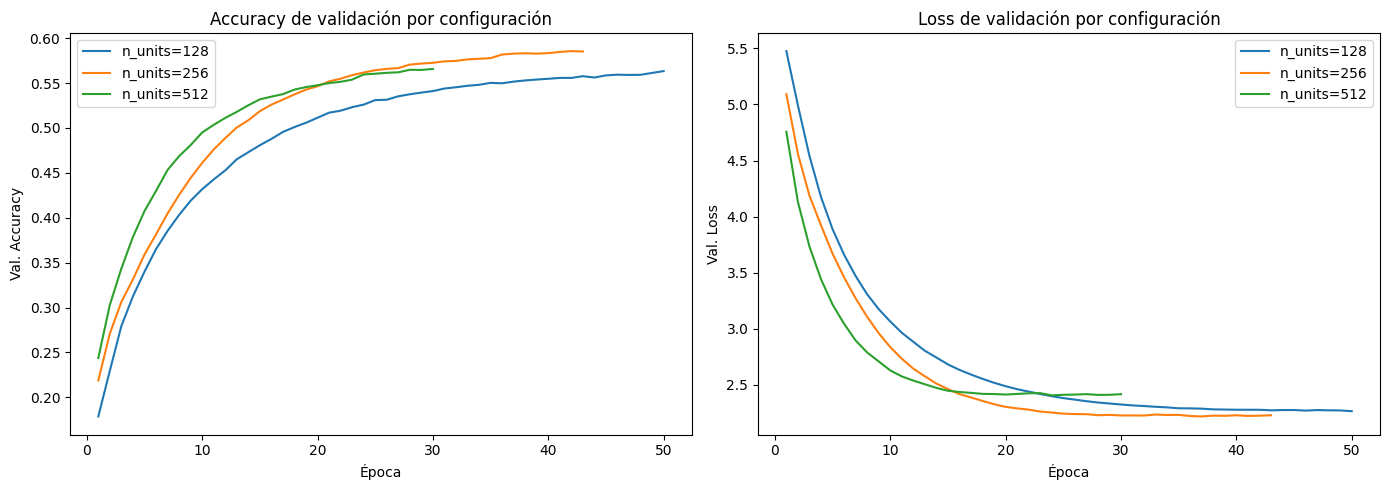

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_units, hist in histories.items():
    epoch_count = range(1, len(hist['val_accuracy']) + 1)
    sns.lineplot(x=epoch_count, y=hist['val_accuracy'], label=f'n_units={n_units}', ax=axes[0])
    sns.lineplot(x=epoch_count, y=hist['val_loss'], label=f'n_units={n_units}', ax=axes[1])

axes[0].set_title("Accuracy de validación por configuración")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Val. Accuracy")

axes[1].set_title("Loss de validación por configuración")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Val. Loss")

plt.tight_layout()
plt.show()

Con 256 unidades se obtiene el mejor `val_accuracy` (0.586) y el `val_loss` más bajo (2.22), deteniéndose por `EarlyStopping` en la época 43. El modelo de 512 unidades ajusta mejor el set de entrenamiento (`train_loss`=0.99) pero generaliza peor (`val_loss`=2.41) y corta antes (época 30), mientras que 128 unidades agota las 50 épocas sin activar `EarlyStopping` y queda por debajo en ambas métricas de validación.

Elegimos automáticamente, en base a `val_accuracy`, la mejor configuración para continuar con la etapa de inferencia y traducción.

In [23]:
best_n_units = results_df['val_accuracy'].astype(float).idxmax()
best_n_units = int(best_n_units)
print(f"Mejor configuración según val_accuracy: n_units = {best_n_units}")
print(results_df.loc[best_n_units])

model, best_components = trained_models[best_n_units]
enc_inputs      = best_components['enc_inputs']
enc_emb_layer   = best_components['enc_emb_layer']
enc_lstm_layer  = best_components['enc_lstm_layer']
dec_inputs      = best_components['dec_inputs']
dec_emb_layer   = best_components['dec_emb_layer']
dec_lstm_layer  = best_components['dec_lstm_layer']
dec_dense_layer = best_components['dec_dense_layer']
n_units         = best_n_units

hist = type('H', (), {'history': histories[best_n_units]})()

Mejor configuración según val_accuracy: n_units = 256
n_units              2.560000e+02
parametros           7.595680e+06
epocas_entrenadas    4.300000e+01
seg_por_epoca        2.695039e+01
train_loss           1.012950e+00
train_accuracy       7.485930e-01
val_loss             2.218817e+00
val_accuracy         5.855396e-01
Name: 256, dtype: float64


Visualizamos el accuracy durante el entrenamiento del modelo elegido

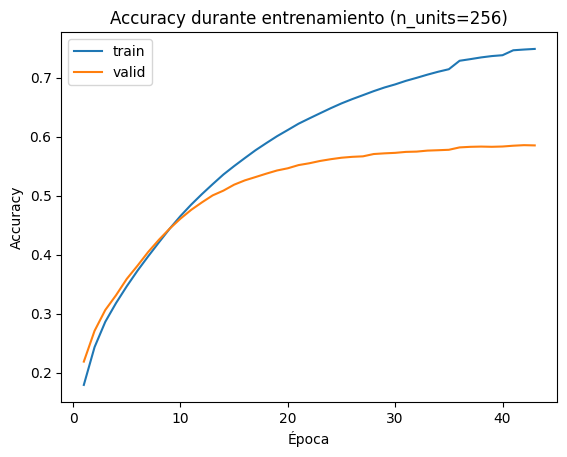

In [24]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title(f"Accuracy durante entrenamiento (n_units={best_n_units})")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

Vemos que en este caso el modelo tiene un leve sobreajuste a partir de la epoca 12 aprox

### **Inferencia Modelo Seq2Seq**

Definimos el modelo Seq2Seq para realizar inferencia

In [25]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [26]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

Aplicamos inferencia greedy

In [27]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Definimos funciones para realizar traducciones

In [28]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

Decodificación por **beam search**

Como actividad opcional, implementamos una variante de *beam search* sobre el mismo decoder, en lugar de la búsqueda *greedy* (que en cada paso solo se queda con el token más probable). *Beam search* mantiene las `k` hipótesis más probables en cada paso y al final elige la de mayor probabilidad acumulada.

In [29]:
def translate_sentence_beam(input_seq, beam_width=3):
    h0, c0 = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # Cada hipótesis: (secuencia_de_tokens, log_prob_acumulada, h, c, terminada)
    beams = [([sos], 0.0, h0, c0, False)]

    for _ in range(max_out_len):
        all_candidates = []
        for seq_tokens, log_prob, h, c, done in beams:
            if done:
                all_candidates.append((seq_tokens, log_prob, h, c, done))
                continue

            target_seq = np.array([[seq_tokens[-1]]])
            output_tokens, h_new, c_new = decoder_model.predict([target_seq, h, c], verbose=0)
            probs = output_tokens[0, 0, :]

            top_k = np.argsort(probs)[-beam_width:]
            for idx in top_k:
                p = probs[idx]
                new_log_prob = log_prob + np.log(p + 1e-10)
                new_seq = seq_tokens + [int(idx)]
                new_done = (idx == eos)
                all_candidates.append((new_seq, new_log_prob, h_new, c_new, new_done))

        # nos quedamos con las beam_width hipótesis más probables
        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = all_candidates[:beam_width]

        if all(b[4] for b in beams):
            break

    best_seq = beams[0][0]
    words = [idx2word_target[i] for i in best_seq[1:] if i != eos and i in idx2word_target]
    return ' '.join(words)


def translate_beam(text, beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence_beam(seq, beam_width=beam_width)

Realizamos pruebas

In [30]:
print("--- Ejemplos del dataset (greedy vs. beam search) ---\n")
sample_idxs = np.random.choice(len(input_sentences), size=5, replace=False)
for i in sample_idxs:
    seq         = encoder_input_sequences[i:i+1]
    pred_greedy = translate_sentence(seq)
    pred_beam   = translate_sentence_beam(seq, beam_width=3)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real):     {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (greedy):   {pred_greedy}")
    print(f"ES (beam k=3): {pred_beam}\n")

--- Ejemplos del dataset (greedy vs. beam search) ---

EN: He's the one, isn't he?
ES (real):     Es él, ¿verdad?
ES (greedy):   él es lo que no
ES (beam k=3): él es lo normal

EN: How's it going at school?
ES (real):     ¿Cómo te va en la escuela?
ES (greedy):   voy a la escuela
ES (beam k=3): voy a la escuela

EN: I obeyed the rules.
ES (real):     Obedecí las normas.
ES (greedy):   he olvidado la normas
ES (beam k=3): las normas

EN: I've never seen one.
ES (real):     Nunca había visto uno.
ES (greedy):   nunca he visto una vez
ES (beam k=3): nunca me he visto

EN: You must've dropped them.
ES (real):     Tienen que habérsete caído.
ES (greedy):   no has dejado de
ES (beam k=3): debiste haber caído



In [31]:
nuevas_frases = [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning languages.",
    "Can you help me?",
    "The weather is very nice today.",
    "I would like to book a table for two.",
    "She has been living in Buenos Aires for three years.",
]

print("--- Frases nuevas (greedy vs. beam search) ---\n")
for s in nuevas_frases:
    greedy_pred = translate(s)
    beam_pred   = translate_beam(s, beam_width=3)
    print(f"EN:            {s}")
    print(f"ES (greedy):   {greedy_pred}")
    print(f"ES (beam k=3): {beam_pred}\n")

--- Frases nuevas (greedy vs. beam search) ---

EN:            My mother says hi.
ES (greedy):   mi madre se llama
ES (beam k=3): mi madre se llama

EN:            Where is the train station?
ES (greedy):   dónde está el tren de buses
ES (beam k=3): dónde está el tren de buses

EN:            I love learning languages.
ES (greedy):   me encanta aprender idiomas
ES (beam k=3): me encanta aprender idiomas

EN:            Can you help me?
ES (greedy):   puedes ayudarme
ES (beam k=3): puedes ayudarme

EN:            The weather is very nice today.
ES (greedy):   hoy hace muy buen día
ES (beam k=3): hoy hace muy buen día

EN:            I would like to book a table for two.
ES (greedy):   me gustaría comprar una mesa y
ES (beam k=3): me gustaría comprar una mesa y

EN:            She has been living in Buenos Aires for three years.
ES (greedy):   ella ha estado viviendo en días de años
ES (beam k=3): ella ha estado viviendo viviendo desde mañana



Calculamos, a modo de métrica adicional, el **accuracy a nivel de palabra** del modelo elegido sobre el conjunto de validación (comparando el token predicho contra el token real, ignorando el padding), para complementar la interpretación cualitativa de las traducciones.

In [32]:
def word_level_accuracy(model, encoder_seqs, decoder_in_seqs, decoder_out_seqs, num_classes, n_batches=20, batch_size=64):
    """Aproxima el accuracy a nivel de palabra evaluando por batches sobre un tf.data.Dataset."""
    ds = make_dataset(encoder_seqs, decoder_in_seqs, decoder_out_seqs, batch_size, num_classes)
    total_correct, total_tokens = 0, 0
    for i, ((enc, dec_in), y_true) in enumerate(ds.take(n_batches)):
        y_pred = model.predict([enc, dec_in], verbose=0)
        pred_ids = np.argmax(y_pred, axis=-1)
        true_ids = y_true.numpy()          # ya son índices enteros, no hace falta argmax
        mask = true_ids != 0  # ignoramos el padding
        total_correct += np.sum((pred_ids == true_ids) & mask)
        total_tokens  += np.sum(mask)
    return total_correct / max(total_tokens, 1)


val_word_acc = word_level_accuracy(
    model,
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    num_words_output
)
print(f"Accuracy a nivel de palabra (validación, ignorando padding): {val_word_acc:.4f}")

Accuracy a nivel de palabra (validación, ignorando padding): 0.5794


## **Interpretación de resultados y conclusiones**

**1. Impacto del tamaño del dataset y de la longitud de secuencia**

Al pasar de 10.000 a 110.000 oraciones y de secuencias de 20/22 a 25/27 tokens, el modelo dispone de muchos más ejemplos y de contextos más largos para aprender la alineación entre inglés y español. Esto se traduce en:
- Mayor accuracy de validación estable (menos overfitting temprano) que con el dataset chico, porque el vocabulario y las estructuras sintácticas están mejor representadas.
- Oraciones más largas permiten cubrir mas casos, pero también hacen más difícil el entrenamiento porque el decoder debe mantener información relevante durante más pasos.

**2. Impacto del número de unidades LSTM (`n_units`)**

Al comparar `n_units` = 128, 256 y 512 sobre el mismo dataset se observa que:
- El modelo de **128 unidades** no llegó a activar `EarlyStopping` y agotó las 50 épocas del entrenamiento, quedando con el `val_accuracy` más bajo de los tres (0.563) — señal de que la capacidad es insuficiente para aprovechar todo el dataset disponible.
- El modelo de **256 unidades** fue el de mejor desempeño: `val_accuracy` = 0.586 y `val_loss` = 2.22, deteniéndose por `EarlyStopping` en la época 43.
- El modelo de **512 unidades**, pese a tener más de 4 veces los parámetros de 128 unidades, no superó a 256: su `val_loss` (2.41) fue el peor de los tres, y su `val_accuracy` (0.566) quedó prácticamente igual al de 128 unidades. Su `train_loss` (0.99) y `train_accuracy` (0.756) sí fueron los mejores del grupo, y cortó por `EarlyStopping` en la época 30 — la más temprana —, lo que indica que memoriza el conjunto de entrenamiento más rápido de lo que generaliza.
- El patrón no es de rendimientos decrecientes sino **negativos** a partir de cierto punto: 256 unidades es el punto óptimo para este dataset y esta arquitectura, y agregar más capacidad (512) empeora la generalización en lugar de mejorarla. Esto es consistente con que el cuello de botella del modelo no está en la capacidad del encoder sino en el vector de contexto de tamaño fijo que conecta encoder y decoder — una limitación estructural que más `n_units` no resuelve.

**3. Calidad de las traducciones generadas**

Con el modelo de 256 unidades se observa una diferencia marcada según la longitud y frecuencia de la construcción:
- Frases cortas y frecuentes se traducen bien o casi perfecto: *"I love learning languages."* → *"me encanta aprender idiomas"*, *"Can you help me?"* → *"puedes ayudarme"*, *"The weather is very nice today."* → *"hoy hace muy buen día"*.
- Construcciones más largas o con tiempos verbales compuestos se degradan: *"She has been living in Buenos Aires for three years."* dio *"ella ha estado viviendo en días de años"* (greedy) y *"ella ha estado viviendo viviendo desde mañana"* (beam, con repetición de palabra) — el modelo pierde la estructura de "llevar X años haciendo algo". De forma similar, *"I would like to book a table for two."* tradujo el verbo "reservar" como "comprar", una confusión semántica típica de vocabulario poco frecuente en el dataset.
- La comparación entre greedy y beam search no mostró una mejora sistemática: en algunos casos beam produce una traducción más razonable (*"You must've dropped them."* → *"debiste haber caído"* en vez de *"no has dejado de"*), pero en otros beam repite palabras o empeora la salida (el ejemplo de Buenos Aires arriba). Con secuencias tan cortas y un espacio de búsqueda relativamente simple, la ventaja de beam search sobre greedy es marginal en este modelo.
- El accuracy a nivel de palabra calculado de forma independiente sobre el set de validación dio **0.579**, consistente con el `val_accuracy` de Keras (0.586) para la misma configuración — lo que confirma que la métrica reportada durante el entrenamiento es representativa y no está siendo inflada por el padding.

**4. Limitaciones del enfoque**

- **Sin mecanismo de atención**: todo el contexto de la oración de entrada se comprime en un único vector de estado (h, c) del encoder. Es la limitación más visible en los ejemplos: las oraciones más largas (más de 8-10 palabras) son las que peor traducen, justamente porque un solo vector de tamaño fijo no alcanza para retener toda la información relevante.
- **Vocabulario limitado** (`MAX_VOCAB_SIZE` = 12.000): palabras poco frecuentes (como "reservar") no están bien representadas y el modelo las reemplaza por alternativas más comunes mal ajustadas al contexto.
- **Embeddings preentrenados solo del lado de entrada** (inglés, GloVe de 50 dimensiones): el lado de salida (español) aprende sus embeddings desde cero, lo que podría mejorarse incorporando embeddings preentrenados también para español.
- **Evaluación**: se usó accuracy a nivel de token/palabra como métrica cuantitativa, pero esta métrica es sensible al orden exacto de las palabras y no captura traducciones válidas pero con distinto fraseo (como el caso de "how's it going at school" → "voy a la escuela", semánticamente relacionado pero no una traducción literal). Una métrica como BLEU sería más adecuada para una evaluación más rigurosa.